In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Lab 10: EEG

## Actividad de aula invertida

Observe el siguiente video que le dará una breve introducción al EEG. Después de verlo se reponderán preguntas que haya sobre el video:

https://www.youtube.com/watch?v=GDgInyAn-C8

### EEG

Los registros de voltaje de la superficie del cuero cabelludo (el electroencefalograma o EEG) proporcionan una poderosa ventana a la actividad del voltaje cerebral. Algunos de los primeros registros de EEG humanos se produjeron en 1924, cuando el Dr. Hans Berger hizo un descubrimiento notable: el EEG de un sujeto humano en reposo con los ojos cerrados exhibe actividad rítmica, una oscilación de aproximadamente 10 Hz que denominó ritmo alfa. Aunque ya se ha estudiado durante casi 100 años, el papel funcional definitivo (si lo hay) del ritmo alfa sigue siendo desconocido. Desde entonces, se han detectado y etiquetado muchos otros ritmos EEG (normalmente con letras griegas) y el análisis de los ritmos EEG sigue siendo un área activa de investigación.

En comparación con otras modalidades para medir la actividad cerebral, el EEG posee ventajas y desventajas. Quizás las ventajas más importantes sean:

1. El EEG no es invasivo y
2. El EEG permite una alta resolución temporal (del orden de milisegundos).

Sin embargo, la medida EEG también adolece de importantes desventajas, siendo la más devastadora la mala resolución espacial; un único electrodo en el cuero cabelludo detecta la actividad sumada de aproximadamente 10 cm$^2$ de corteza.

En este cuaderno, consideramos los datos de EEG registrados con un único electrodo en el cuero cabelludo. Analizaremos estos datos para determinar qué actividad (si la hay) se evoca después de dos tipos diferentes de estímulos presentados a un sujeto humano. Al hacerlo, usaremos Python y veremos cómo esta poderosa herramienta puede ayudarnos a comprender estos datos de series temporales. Comenzamos con una breve descripción de los datos del EEG.

## Caso de estudio

Un estudiante universitario se ofrece como voluntario para participar en un estudio de psicología en su universidad. En este estudio, se colocan electrodos de EEG (frecuencia de muestreo de 500 Hz, es decir, 500 muestras por segundo) en el cuero cabelludo del estudiante y se lo sienta en una silla cómoda en una habitación oscura y aislada eléctricamente. Se le indica al estudiante que se coloque auriculares en los oídos y escuche una serie de sonidos repetidos. Los sonidos constan de dos tonos: un tono alto o un tono bajo. Se presenta un solo tono una vez cada pocos segundos y el estudiante responde presionando un botón al tono grave. La presentación del tono se repite para recopilar la respuesta del EEG a numerosas presentaciones de los dos tonos, como se ilustra aquí:

![EEG_1.png](attachment:EEG_1.png)

En esta caricatura del experimento EEG, los electrodos EEG se colocan en la superficie del cuero cabelludo de un sujeto humano (izquierda). La actividad EEG (azul) se registra en función del tiempo durante la presentación de tonos altos (negro) y tonos bajos (naranja).

Nuestra colaboradora que dirige este estudio de investigación acordó proporcionarnos datos de EEG registrados en un solo electrodo para 1000 presentaciones del tono alto y 1000 presentaciones del tono bajo. En cada presentación, o "prueba", nos proporciona 1 s de datos de EEG, de modo que el tono se produce a los 0,25 s de iniciada la prueba. Ella nos pide que analicemos estos datos para determinar si la señal EEG difiere después de las presentaciones de los dos tonos.

## Análisis de datos

1. Utilice la función scipy.io.loadmat para cargar los datos adjuntos. Las series de tiempo que nos interesan son EEGa y EEGb correspondientes a las 1000 repeticiones del tono alto y del tono bajo. A partir del tamaño del arreglo EEGa o EEGb determine el número de muestras y el número de repeticiones.

In [3]:
data = scipy.io.loadmat('Ch2-EEG-1.mat')
EEGa = data["EEGa"]
EEGb = data["EEGb"]
t = data["t"]

In [4]:
print("Para Tono alto:")
print("El número de muestras es: ", EEGa.shape[1])
print("El número de repeticiones es: ", EEGa.shape[0])
print()
print("Para Tono bajo:")
print("El número de muestras es: ", EEGb.shape[1])
print("El número de repeticiones es: ", EEGb.shape[0])
print()
EEGa.shape, EEGb.shape

Para Tono alto:
El número de muestras es:  500
El número de repeticiones es:  1000

Para Tono bajo:
El número de muestras es:  500
El número de repeticiones es:  1000



((1000, 500), (1000, 500))

2. Grafique 5 trazas de tiempo de EEGa y de EEGb a manera de subplots y determine si encuentra alguna diferencia cualtitiva entre las trazas de una condición y la otra. Haga una barra vertical en cada subplot para indicar el momento de presentación del estímulo.

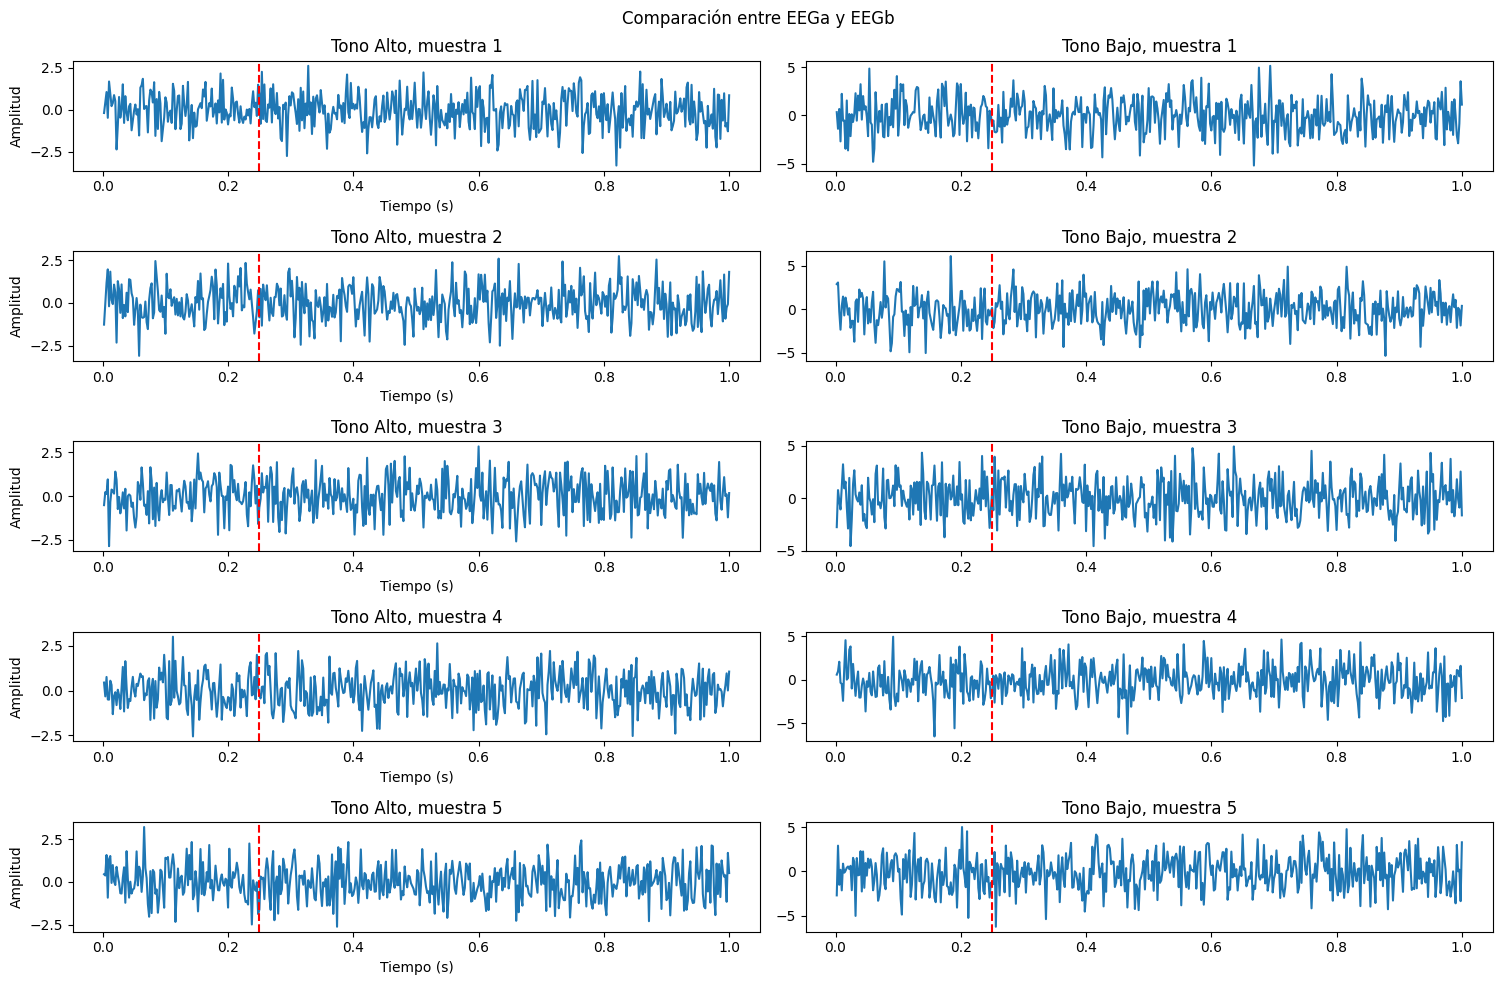

In [5]:
plt.figure(figsize=(15, 10))
plt.suptitle("Comparación entre EEGa y EEGb")
for i in range(5):
  plt.subplot(5, 2, 2 * i + 1)
  plt.plot(t.T, EEGa[i, :])
  plt.axvline(x=0.25, color='r', linestyle='--')
  plt.xlabel('Tiempo (s)')
  plt.ylabel('Amplitud')
  plt.title(f"Tono Alto, muestra {i+1}")
  plt.subplot(5, 2, 2 *(i+1))
  plt.plot(t.T, EEGb[i, :])
  plt.axvline(x=0.25, color='r', linestyle='--')
  plt.title(f"Tono Bajo, muestra {i+1}")
plt.tight_layout()
plt.show()

Notemos que realizando graficas por muestras individuales no se puede determinar algo relevante o clave, de hecho en la mayoría de estos plots sería complicado determinar donde es el estímulo solo por su forma.

3. Utilice la función imshow para mostrar en un gráfico de mapa de calor los 1000 ensayos diferentes para EEGa y EEGb, asegúrese de agregar nuevamente la barra vertical. Puede decir algo de esta inspección visual?

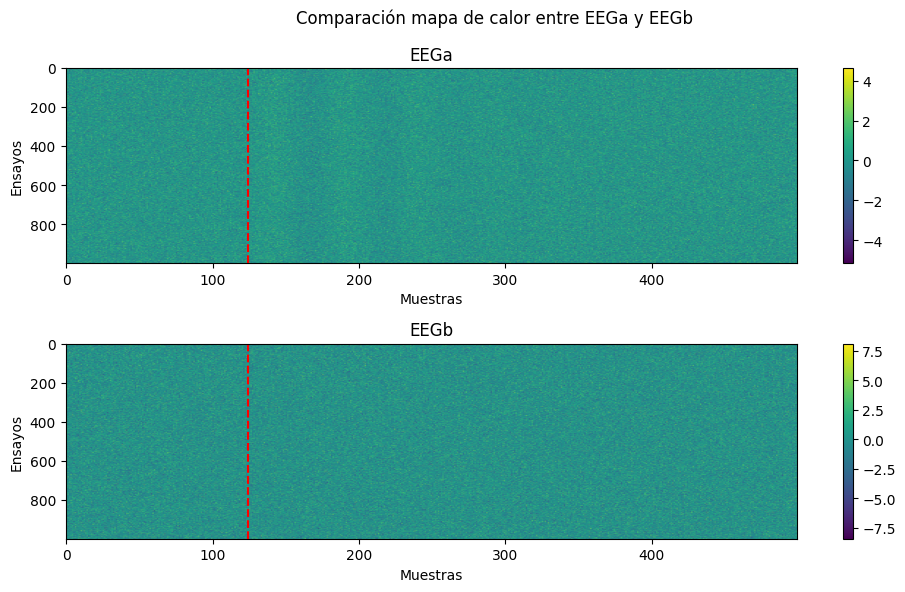

In [7]:
indice_estimulo = np.where(t == 0.25)[1][0]

plt.figure(figsize=(10, 6))
plt.suptitle("Comparación mapa de calor entre EEGa y EEGb")
plt.subplot(2, 1, 1)
plt.imshow(EEGa, aspect="auto", cmap='viridis')
plt.xlabel('Muestras')
plt.ylabel('Ensayos')
plt.axvline(x=indice_estimulo, color='r', linestyle='--')
plt.colorbar()
plt.title("EEGa")

plt.subplot(2, 1, 2)
plt.imshow(EEGb, aspect="auto", cmap='viridis')
plt.xlabel('Muestras')
plt.ylabel('Ensayos')
plt.axvline(x=indice_estimulo, color='r', linestyle='--')
plt.colorbar()
plt.title("EEGb")

plt.tight_layout()
plt.show()

Tampoco es muy relevante la información que nos ofrece esta gráfica, sin embargo, en el estimulo alto (EEGa) se puede notar algunos patrones verticales después de aplicado el estimulo, quizas debido a alguna oscilación presente.

La inspección visual de los datos del EEG hasta ahora no ha dado resultados. Los trazos del EEG parecen ruidosos o quizás rítmicos, pero a partir de la inspección visual de los ensayos individuales es difícil llegar a una conclusión decisiva sobre la estructura subyacente. Para investigar más a fondo la actividad en estos datos, calculamos el **potencial relacionado con eventos** (ERP).

Para calcular el ERP, primero asumimos que cada prueba evoca una instancia del mismo proceso cerebral subyacente. Entonces, en este caso, asumimos que la misma respuesta cerebral se evoca 1000 veces (una por cada prueba) para cada condición. Sin embargo, la respuesta evocada debido al estímulo es pequeña y está oculta en la señal del EEG por otra actividad en curso no relacionada con el estímulo (p. ej., soñar despierto, pensamientos sobre la cena, pensamientos sobre la tarea). Por lo tanto, para descubrir el débil efecto evocado, **promediamos las respuestas del EEG entre los ensayos**. Idealmente, la actividad EEG no relacionada con el estímulo se cancelará en promedio, mientras que la actividad EEG evocada por el estímulo se sumará de manera constructiva.

4. Calcule el ERP de las dos condiciones

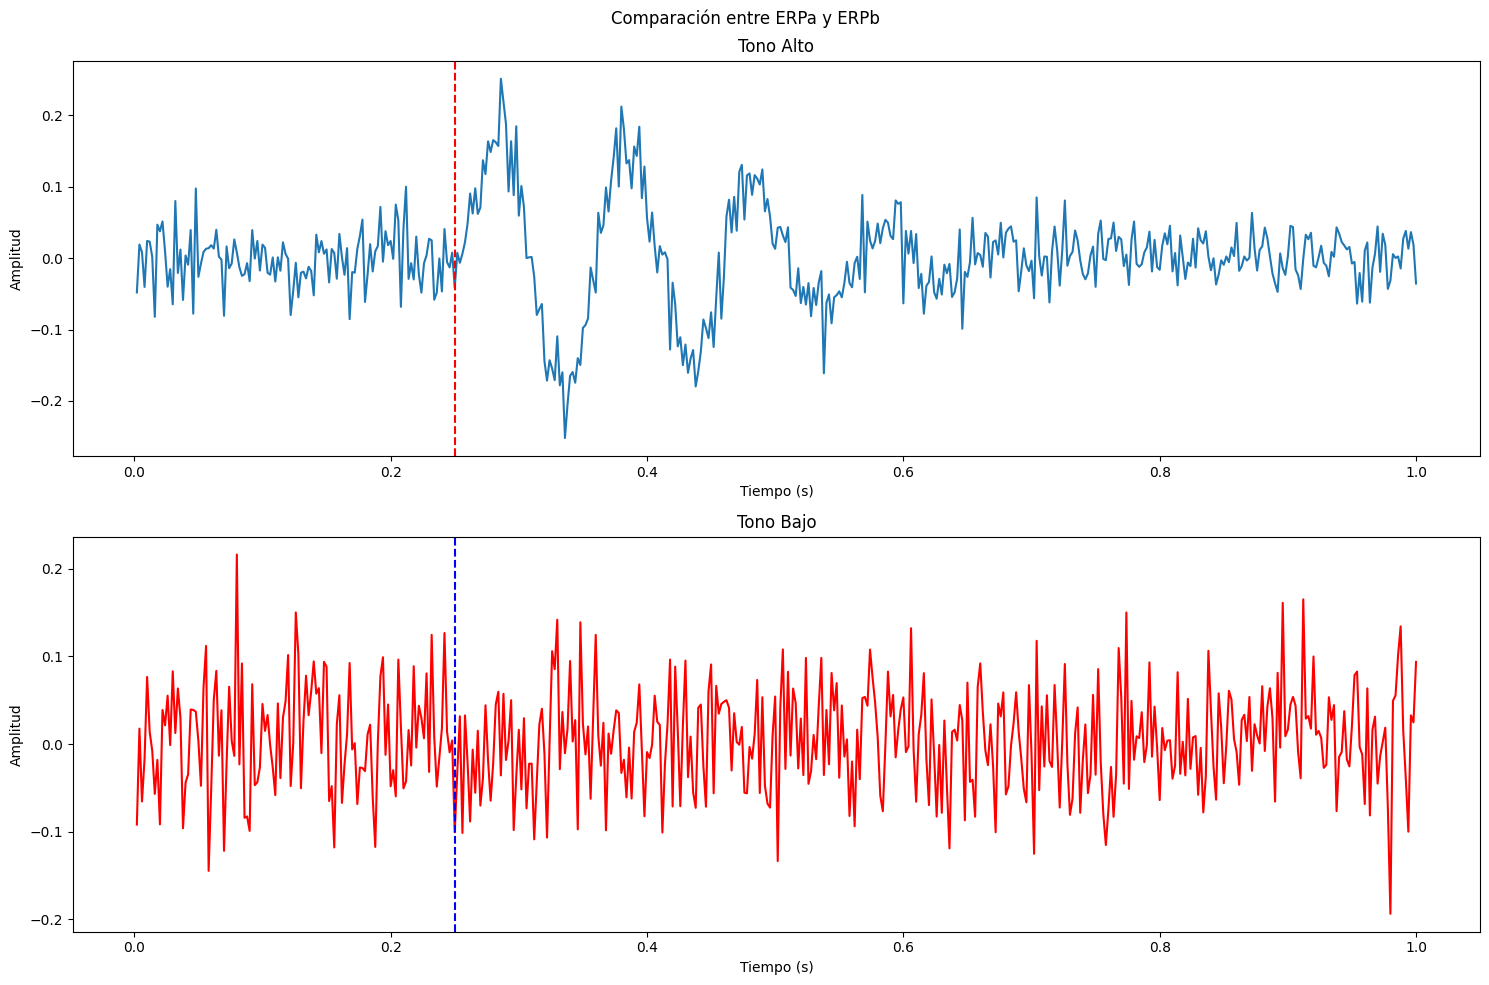

In [8]:
ERPa = np.mean(EEGa, axis=0)
ERPb = np.mean(EEGb, axis=0)

plt.figure(figsize=(15, 10))
plt.suptitle("Comparación entre ERPa y ERPb")

plt.subplot(2, 1, 1)
plt.plot(t.T, ERPa)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.axvline(x=0.25, color='r', linestyle='--')
plt.title("Tono Alto")

plt.subplot(2, 1, 2)
plt.plot(t.T, ERPb,"r")
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.axvline(x=0.25, color='b', linestyle='--')
plt.title("Tono Bajo")

plt.tight_layout()
plt.show()

Para calcular el ERP promediamos los datos del EEG en muchos ensayos. Debido a esto, podemos hacer uso de un poderoso teorema en estadística (el teorema del límite central) para incluir límites de confianza aproximados en la figura del ERP. Brevemente, este teorema establece que la **media** de un número suficientemente grande de variables aleatorias independientes, cada una con media y varianza finitas, tendrá una distribución aproximadamente normal.

Recuerde que el ERP en cada momento es la suma de la actividad del EEG en todas las pruebas dividido por el número de pruebas -es decir una media-. Supongamos que los ensayos son independientes (es decir, un ensayo no depende de ningún otro). Supongamos también que los datos del EEG en cada momento tienen media y varianza finitas. Con esos supuestos, hemos satisfecho las condiciones del CLT y, por lo tanto, podemos concluir que el ERP en cada momento tiene una distribución aproximadamente normal.

Esta conclusión (que la ERP en cada momento tiene una distribución aproximadamente normal) es útil porque la distribución normal (también conocida como distribución gaussiana o curva de campana) posee muchas propiedades convenientes. Primero, una distribución normal es relativamente simple; se puede especificar completamente con dos parámetros: el valor medio y la desviación estándar. En segundo lugar, el 95% de los valores extraídos de una distribución normal se encuentran aproximadamente dentro de dos desviaciones estándar de la media.

De acuerdo al Teorema del límite central, con un 95% de confianza la media **verdadera** se encuentra en la media de la muestra $\pm 2 \sigma/\sqrt{n}$. Donde $\sigma$ es la desviación estándar de la muestra.

5. Agregue los intervalos de confianza al ERP y discuta cuáles de las fluctuaciones observadas son significativas.

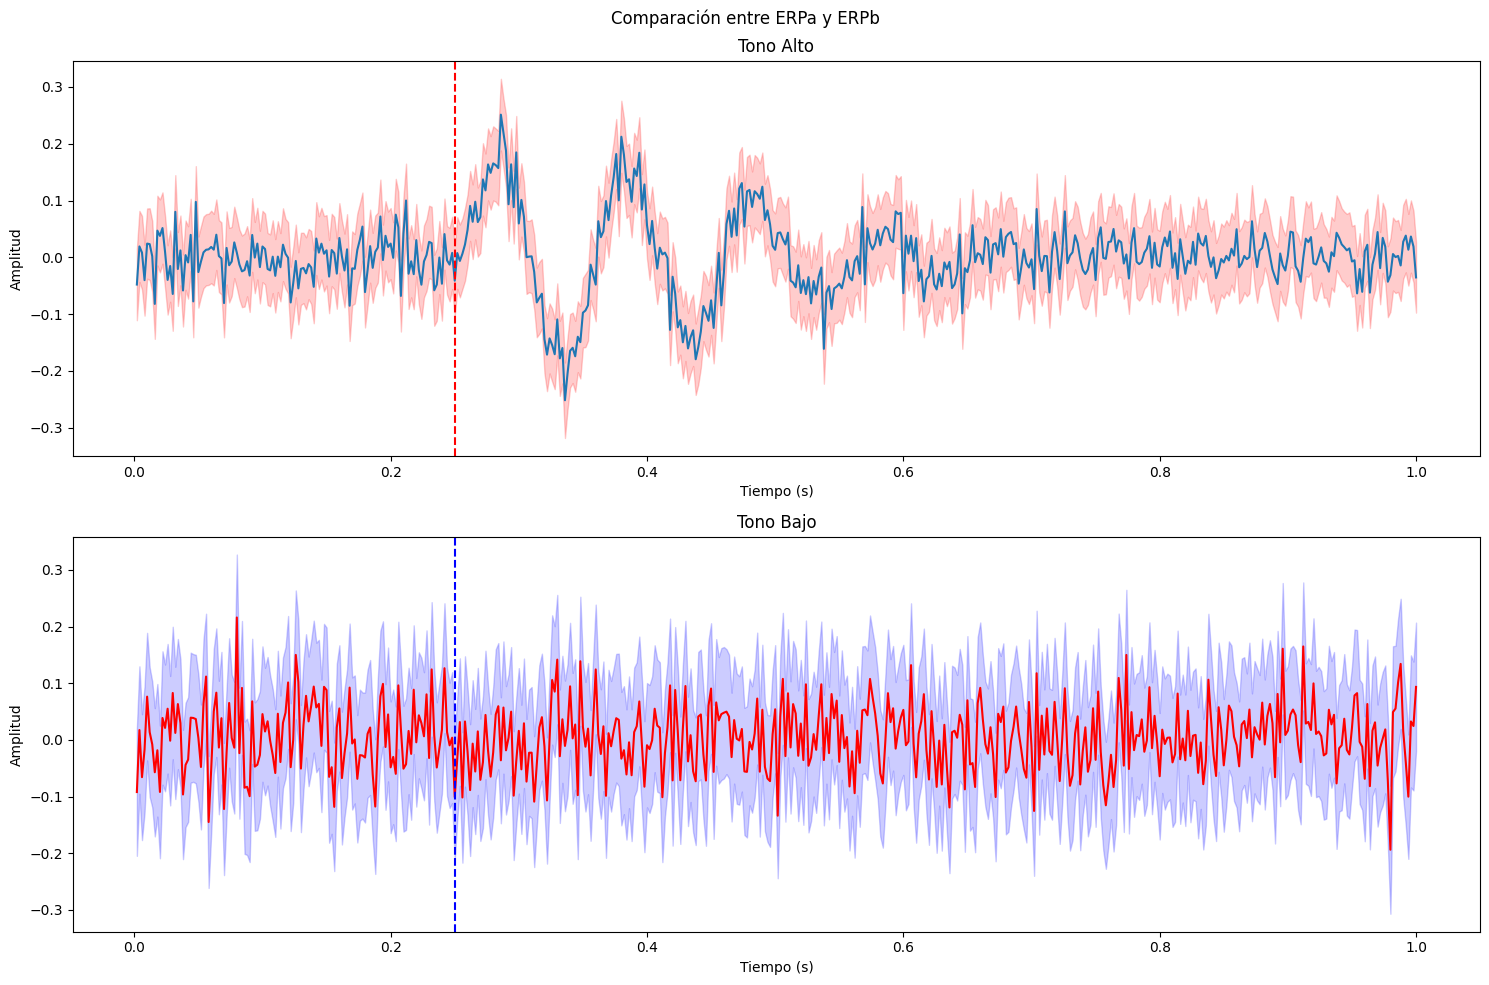

In [9]:
desv_estandar_a = np.std(EEGa,axis = 0)
desv_estandar_b = np.std(EEGb,axis = 0)

cota_sup_a = ERPa + 2 * desv_estandar_a / np.sqrt(1000)
cota_sup_b = ERPb + 2 * desv_estandar_b / np.sqrt(1000)
cota_inf_a = ERPa - 2 * desv_estandar_a / np.sqrt(1000)
cota_inf_b = ERPb - 2 * desv_estandar_b / np.sqrt(1000)

plt.figure(figsize=(15, 10))
plt.suptitle("Comparación entre ERPa y ERPb")

plt.subplot(2, 1, 1)
plt.plot(t.T, ERPa)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.fill_between(t[0], cota_inf_a, cota_sup_a, color='r', alpha=0.2)
plt.axvline(x=0.25, color='r', linestyle='--')
plt.title("Tono Alto")

plt.subplot(2, 1, 2)
plt.plot(t.T, ERPb,"r")
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.fill_between(t[0], cota_inf_b, cota_sup_b, color='b', alpha=0.2)
plt.axvline(x=0.25, color='b', linestyle='--')
plt.title("Tono Bajo")

plt.tight_layout()
plt.show()

Esta gráfica es de las que mayor información nos brinda, sobre todo en EEGa, justamente despues del estimulo notamos un patron oscilante que va disminuyendo con el paso del tiempo. Notemos que en la EEGb se sigue presentando un ruido que hace imposible determinar algo significativo.

Las oscilaciones presentes en la actividad cerebral se suelen dividir en bandas de frecuencia como lo muestra la tabla a continuación:

Dependiendo de la banda presente en la señal original se habla qe la señal tiene una fuerte componente en dicha banda.

6. Calcule la densidad de potencia espectral del ERP para las dos condiciones y discuta qué bandas están presentes en ambos casos  

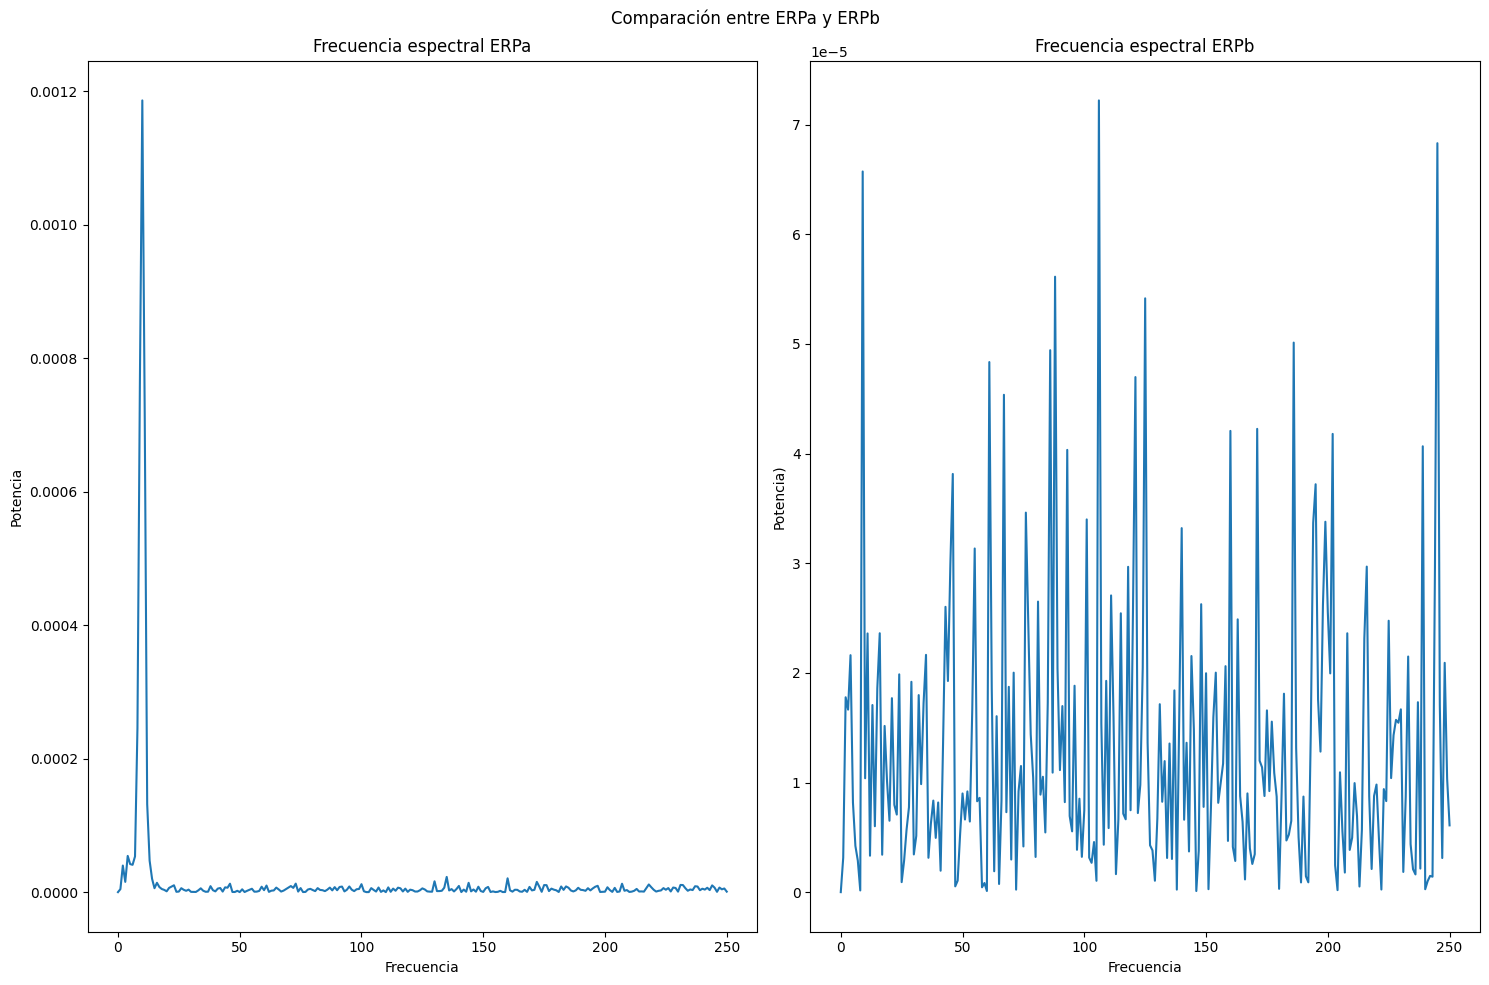

In [ ]:
dt = (t[0][1] - t[0][0])

plt.figure(figsize=(15, 10))
plt.suptitle("Comparación entre ERPa y ERPb")
plt.subplot(1, 2, 1)
frecuencia, potencia = signal.periodogram(ERPa, fs=1/dt)
plt.plot(frecuencia, potencia)
plt.xlabel('Frecuencia')
plt.ylabel('Potencia')
plt.title('Frecuencia espectral ERPa')

plt.subplot(1, 2, 2)
frecuencia, potencia = signal.periodogram(ERPb, fs=1/dt)
plt.plot(frecuencia, potencia)
plt.xlabel('Frecuencia')
plt.ylabel('Potencia)')
plt.title('Frecuencia espectral ERPb')
plt.tight_layout()
plt.show()

En efecto el espectro de potencia de la EEGa nos permite concluir el tipo de comportamiento de la señal ante dicho estimulo, haciendo presente una frecuencia entre 8-13, es decir, una señal alpha, este resultado es bastante acorde a la oscilación presentada en la grafica anterior. En cambio en la grafica de EEGb notamos que la función de densidad de potencia espectral es similar a una plana, concluímos así nuevamente que no hay ningún factor relevante.

Note que el caso del ERP del experimento caso *a* aparece una clara oscilación solo cuando aparece el estímulo, y esta oscilación decae a medida que avanzamos en el tiempo. Esto quiere decir que las frecuencias importantes pueden no aparecer **siempre**, sino solo en momentos puntuales. Para analizar este tipo de comportamiento se suele usar el espectrograma, que es el resultado de calcular el espectro de frecuencias de una señal por pequeñas ventanas de tiempo y no usando toda la señal como lo hemos hecho hasta ahora. El resultado es un mapa de calor en el que en el eje X graficamos el tiempo, en el eje Y las frecuencias y la intensidad del color indicará para un determinado tiempo la cantidad de energía que hay en las distintas frecuencias.

7. Calcule el espectrograma del ERP en ambos experimentos y discuta las diferencias. Para este ejercicio haga uso de la función *spectrogram* del módulo scipy.signal, utilice la ayuda y entienda cómo usar los diferentes parámetros: Para obtener un espectrograma adecuado use "ventanas" de 200ms con traslape del 95\%.

**Nota:** Es habitual presentar la densidad de potencia espectral (la barra de color) de estos gráficos en decibelios, es decir, si la densidad de potencia es $S_{xx}$, muestre en el gráfico $10 \log_{10}(S_{xx})$

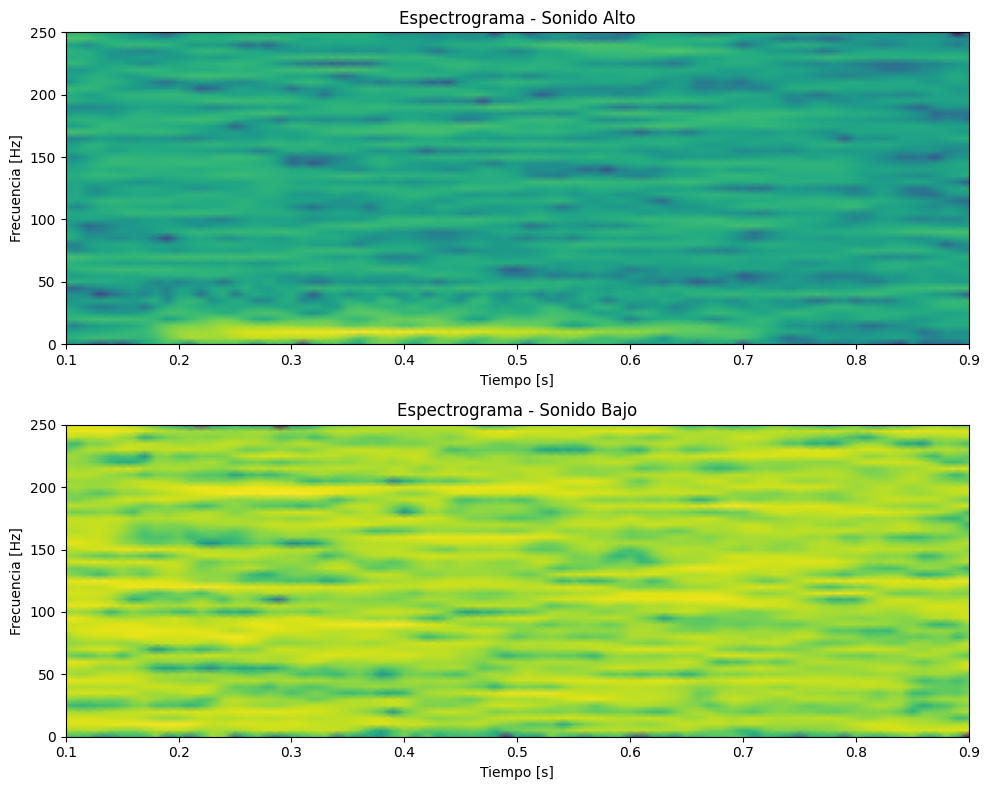

In [ ]:
# Simulación de señales ERP (se deben reemplazar con datos reales)
fs = 500  # Frecuencia de muestreo en Hz

# Parámetros del espectrograma
nperseg = int(0.2 * fs) # Ventana de 200 ms = 0.2 seg
noverlap = int(0.95 * nperseg)  # 95% de traslape

# Cálculo del espectrograma
f1, t1, Sxx1 = signal.spectrogram(ERPa, fs, nperseg=nperseg, noverlap=noverlap)
f2, t2, Sxx2 = signal.spectrogram(ERPb, fs, nperseg=nperseg, noverlap=noverlap)
# Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].pcolormesh(t1, f1, 10 * np.log10(Sxx1), shading='gouraud')
ax[0].set_title('Espectrograma - Sonido Alto')
ax[0].set_ylabel('Frecuencia [Hz]')
ax[0].set_xlabel('Tiempo [s]')

ax[1].pcolormesh(t2, f2, 10 * np.log10(Sxx2), shading='gouraud')
ax[1].set_title('Espectrograma - Sonido Bajo')
ax[1].set_ylabel('Frecuencia [Hz]')
ax[1].set_xlabel('Tiempo [s]')

plt.tight_layout()
plt.show()

Como era de esperar, el espectrograma también nos resume las conclusiones dadas anteriormente, permitiendonos una visualizacion espacio-temporal y logrando determinar que después del estimulo la EEGa presenta un patrón periodico que va disminuyendo hasta perderse a los 0.6 seg